# Section 0: Import Data

> import pandas as pd

df = pd.read_parquet("sample_hotels.parquet")
df.head() 

In [1]:
!pip install statsforecast mlforecast xgboost neuralforecast utilsforecast lightgbm



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
# 1. Imports

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA

from mlforecast import MLForecast
from xgboost import XGBRegressor

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS   # your version uses these

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Global settings
H = 28           # forecast horizon (days)
N_WINDOWS = 5    # 5-fold time-series CV

plt.rcParams["figure.figsize"] = (10, 5)


/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/venv/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /root/venv/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-12-05 05:35:43,194	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-12-05 05:35:43,266	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, the

# Section 1: Load and Inspect Data

In [3]:
import pandas as pd

df = pd.read_parquet("sample_hotels.parquet")
df.head()

df.dtypes

unique_id               object
ds              datetime64[us]
holiday_flag            object
target_day              object
target_month            object
                     ...      
otb_56                 float64
otb_57                 float64
otb_58                 float64
otb_59                 float64
otb_60                 float64
Length: 69, dtype: object

In [4]:
df.columns.tolist()


['unique_id',
 'ds',
 'holiday_flag',
 'target_day',
 'target_month',
 'target_year',
 'location_type',
 'hotel_type',
 'y',
 'otb_1',
 'otb_2',
 'otb_3',
 'otb_4',
 'otb_5',
 'otb_6',
 'otb_7',
 'otb_8',
 'otb_9',
 'otb_10',
 'otb_11',
 'otb_12',
 'otb_13',
 'otb_14',
 'otb_15',
 'otb_16',
 'otb_17',
 'otb_18',
 'otb_19',
 'otb_20',
 'otb_21',
 'otb_22',
 'otb_23',
 'otb_24',
 'otb_25',
 'otb_26',
 'otb_27',
 'otb_28',
 'otb_29',
 'otb_30',
 'otb_31',
 'otb_32',
 'otb_33',
 'otb_34',
 'otb_35',
 'otb_36',
 'otb_37',
 'otb_38',
 'otb_39',
 'otb_40',
 'otb_41',
 'otb_42',
 'otb_43',
 'otb_44',
 'otb_45',
 'otb_46',
 'otb_47',
 'otb_48',
 'otb_49',
 'otb_50',
 'otb_51',
 'otb_52',
 'otb_53',
 'otb_54',
 'otb_55',
 'otb_56',
 'otb_57',
 'otb_58',
 'otb_59',
 'otb_60']

# Section 2: Build the Time Series Data

In [5]:
ts_df = (
    df[["unique_id", "ds", "y"]]
    .sort_values(["unique_id", "ds"])
)

ts_df.head()


,unique_id,ds,y
1430,hotel_0,2022-01-01,0.975309
1431,hotel_0,2022-01-02,0.493827
1432,hotel_0,2022-01-03,0.456790
1433,hotel_0,2022-01-04,0.592593
1434,hotel_0,2022-01-05,0.530864


In [6]:
ts_df = (
    df[["unique_id", "ds", "y"]]
    .sort_values(["unique_id", "ds"])
)

ts_df.head()


,unique_id,ds,y
1430,hotel_0,2022-01-01,0.975309
1431,hotel_0,2022-01-02,0.493827
1432,hotel_0,2022-01-03,0.456790
1433,hotel_0,2022-01-04,0.592593
1434,hotel_0,2022-01-05,0.530864


In [7]:

!pip install statsforecast

# Now, import the necessary modules
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA

# Define models
sf_models = [
    Naive(),
    SeasonalNaive(season_length=7),
    AutoETS(),
    AutoARIMA()
]

# Create StatsForecast object (no df here)
sf = StatsForecast(
    models=sf_models,
    freq="D",
    n_jobs=-1
)

# 5-fold cross-validation (df passed here)
sf_cv = sf.cross_validation(
    df=ts_df,
    h=28,
    n_windows=5,
    step_size=28,
    refit=True,
    level=[]
)

sf_cv.head()


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.727752,0.721194
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.727752,0.759476
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.727752,0.779672
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.727752,0.779672
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.727752,0.779672


In [8]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape   # ← use these


In [9]:
sf_model_names = ["Naive", "SeasonalNaive", "AutoETS", "AutoARIMA"]

metrics_sf = evaluate(
    sf_cv,
    metrics=[mae, rmse, mape],
    models=sf_model_names,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
)

metrics_sf


,unique_id,cutoff,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_77,2022-07-23,mae,0.000439,0.000439,4.393673e-04,0.000530
1,hotel_77,2022-08-20,mae,0.001130,0.001130,1.129827e-03,0.001130
2,hotel_77,2022-09-17,mae,0.002071,0.001946,2.071404e-03,0.002003
3,hotel_77,2022-10-15,mae,0.009164,0.003892,9.166616e-03,0.006283
4,hotel_77,2022-11-22,mae,0.000000,0.000000,6.254024e-08,0.000621
...,...,...,...,...,...,...,...
280,hotel_7,2023-06-02,mape,0.716212,0.514262,7.162092e-01,0.547235
281,hotel_70,2023-06-02,mape,0.128150,0.288243,4.731953e-01,0.262097
282,hotel_84,2023-06-02,mape,0.108934,0.163925,1.429077e-01,0.133975
283,hotel_91,2023-06-02,mape,0.093757,0.152336,8.956764e-02,0.080765


In [10]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape

sf_model_names = ["Naive", "SeasonalNaive", "AutoETS", "AutoARIMA"]

metrics_sf = evaluate(
    sf_cv,
    metrics=[mae, rmse, mape],
    models=sf_model_names,
    id_col="unique_id",
    time_col="ds",
    target_col="y"
)


In [11]:
# Names of the model columns in sf_cv
sf_model_names = ["Naive", "SeasonalNaive", "AutoETS", "AutoARIMA"]

metrics_sf = evaluate(
    sf_cv,
    metrics=[mae, rmse, mape],     # use the custom metric functions
    models=sf_model_names,         # tell evaluate which columns are models
    id_col="unique_id",
    time_col="ds",
    target_col="y",
)

metrics_sf.head()


,unique_id,cutoff,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_77,2022-07-23,mae,0.000439,0.000439,4.393673e-04,0.000530
1,hotel_77,2022-08-20,mae,0.001130,0.001130,1.129827e-03,0.001130
2,hotel_77,2022-09-17,mae,0.002071,0.001946,2.071404e-03,0.002003
3,hotel_77,2022-10-15,mae,0.009164,0.003892,9.166616e-03,0.006283
4,hotel_77,2022-11-22,mae,0.000000,0.000000,6.254024e-08,0.000621


# Step 3: Metrics

In [12]:
import numpy as np
import pandas as pd

def compute_metrics_group(group, pred_col):
    y_true = group["y"]
    y_pred = group[pred_col]
    
    me = (y_true - y_pred).mean()
    mae = (y_true - y_pred).abs().mean()
    rmse = np.sqrt(((y_true - y_pred)**2).mean())
    mape = ((y_true - y_pred).abs() / y_true.replace(0, np.nan)).mean() * 100
    
    return pd.Series({
        "ME": me, 
        "MAE": mae, 
        "RMSE": rmse, 
        "MAPE": mape
    })


In [13]:
rows = []
for m in sf_models:
    mname = m.__class__.__name__
    pred_col = mname
    
    tmp = sf_cv[["unique_id", "ds", "y", pred_col]].dropna()
    
    metrics = tmp.groupby("unique_id").apply(
        lambda g: compute_metrics_group(g, pred_col)
    ).reset_index()
    
    metrics["model"] = mname
    rows.append(metrics)

sf_metrics_by_hotel = pd.concat(rows, ignore_index=True)
sf_metrics_by_hotel.head()


,unique_id,ME,MAE,RMSE,MAPE,model
0,hotel_0,-0.082011,0.194709,0.252434,34.109032,Naive
1,hotel_105,-0.053190,0.120036,0.159475,16.684634,Naive
2,hotel_112,0.064643,0.141250,0.169385,16.263975,Naive
3,hotel_126,-0.009562,0.035515,0.064730,4.166053,Naive
4,hotel_133,-0.014520,0.107494,0.143571,13.583397,Naive


In [14]:
idx = sf_metrics_by_hotel.groupby("unique_id")["MAE"].idxmin()
sf_winners = sf_metrics_by_hotel.loc[idx, ["unique_id", "model"]]

sf_winners["model"].value_counts()


model
AutoARIMA        9
AutoETS          5
Naive            3
SeasonalNaive    2
Name: count, dtype: int64

In [15]:
import os
os.makedirs("results", exist_ok=True)

sf_metrics_by_hotel.to_csv("results/sf_cv_metrics_by_hotel.csv", index=False)
sf_winners.to_csv("results/sf_classical_mae_winners.csv", index=False)


In [16]:
sf_metrics_by_hotel.head()

,unique_id,ME,MAE,RMSE,MAPE,model
0,hotel_0,-0.082011,0.194709,0.252434,34.109032,Naive
1,hotel_105,-0.053190,0.120036,0.159475,16.684634,Naive
2,hotel_112,0.064643,0.141250,0.169385,16.263975,Naive
3,hotel_126,-0.009562,0.035515,0.064730,4.166053,Naive
4,hotel_133,-0.014520,0.107494,0.143571,13.583397,Naive


In [17]:
sf_winners["model"].value_counts()

model
AutoARIMA        9
AutoETS          5
Naive            3
SeasonalNaive    2
Name: count, dtype: int64

In [18]:
!pip install mlforecast xgboost lightgbm



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [19]:
from mlforecast import MLForecast
from xgboost import XGBRegressor

mlf = MLForecast(
    models=[
        XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective="reg:squarederror"
        )
    ],
    freq="D",
    lags=[1, 2, 7, 14]  # standard useful lags
)


In [20]:
# Cross-validation for XGBoost / MLForecast
mlf_cv = mlf.cross_validation(
    df=ts_df,
    h=28,
    n_windows=5,
    step_size=28,
)

mlf_cv.head()


,unique_id,ds,cutoff,y,XGBRegressor
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.770744
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.746864
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.868914
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.909793
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.767246


In [21]:
ml_cv = mlf.cross_validation(
    df=ts_df,
    n_windows=5,
    h=28,
    step_size=28
)

ml_cv.head()


,unique_id,ds,cutoff,y,XGBRegressor
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.770744
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.746864
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.868914
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.909793
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.767246


In [22]:
pred_col = "XGBRegressor"

tmp = ml_cv[["unique_id", "ds", "y", pred_col]].dropna()

ml_metrics_by_hotel = tmp.groupby("unique_id").apply(
    lambda g: compute_metrics_group(g, pred_col)
).reset_index()

ml_metrics_by_hotel["model"] = pred_col

ml_metrics_by_hotel.head()


,unique_id,ME,MAE,RMSE,MAPE,model
0,hotel_0,-0.059065,0.175782,0.225219,30.951702,XGBRegressor
1,hotel_105,0.033915,0.107776,0.130076,13.348735,XGBRegressor
2,hotel_112,0.015943,0.095006,0.113478,11.195886,XGBRegressor
3,hotel_126,0.046187,0.072466,0.086076,7.716511,XGBRegressor
4,hotel_133,-0.004072,0.090858,0.117538,12.009153,XGBRegressor


In [23]:
ml_metrics_by_hotel.to_csv("results/ml_cv_metrics_by_hotel.csv", index=False)


In [24]:
ml_cv.head()

,unique_id,ds,cutoff,y,XGBRegressor
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.770744
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.746864
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.868914
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.909793
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.767246


In [25]:
ml_metrics_by_hotel.head()

,unique_id,ME,MAE,RMSE,MAPE,model
0,hotel_0,-0.059065,0.175782,0.225219,30.951702,XGBRegressor
1,hotel_105,0.033915,0.107776,0.130076,13.348735,XGBRegressor
2,hotel_112,0.015943,0.095006,0.113478,11.195886,XGBRegressor
3,hotel_126,0.046187,0.072466,0.086076,7.716511,XGBRegressor
4,hotel_133,-0.004072,0.090858,0.117538,12.009153,XGBRegressor


# Step 4: Classical Models (StatsForecast)

In [26]:
!pip install statsforecast



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [27]:
# Step 4 — Classical Models (StatsForecast)

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA

# Define classical models
sf_models = [
    Naive(),
    SeasonalNaive(season_length=7),  # Weekly seasonality
    AutoETS(),
    AutoARIMA()
]

# Create StatsForecast object
sf = StatsForecast(
    models=sf_models,
    freq='D',
    n_jobs=-1
)

# Run 5-fold cross-validation (h = 28-day forecast, step = 28)
sf_cv = sf.cross_validation(
    df=ts_df,
    n_windows=5,
    h=28,
    step_size=28
)

sf_cv.head()


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.727752,0.721194
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.727752,0.759476
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.727752,0.779672
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.727752,0.779672
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.727752,0.779672


In [28]:
import numpy as np
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape  # 👈 built-in metric functions

# List of model columns in sf_cv
sf_models = ["Naive", "SeasonalNaive", "AutoETS", "AutoARIMA"]

metrics_sf = evaluate(
    sf_cv,
    metrics=[mae, rmse, mape],   # 👈 pass the FUNCTIONS, not strings
    models=sf_models,            # 👈 tell it which columns are model forecasts
    id_col="unique_id",
    time_col="ds",
    target_col="y",
)

metrics_sf


,unique_id,cutoff,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_77,2022-07-23,mae,0.000439,0.000439,4.393673e-04,0.000530
1,hotel_77,2022-08-20,mae,0.001130,0.001130,1.129827e-03,0.001130
2,hotel_77,2022-09-17,mae,0.002071,0.001946,2.071404e-03,0.002003
3,hotel_77,2022-10-15,mae,0.009164,0.003892,9.166616e-03,0.006283
4,hotel_77,2022-11-22,mae,0.000000,0.000000,6.254024e-08,0.000621
...,...,...,...,...,...,...,...
280,hotel_7,2023-06-02,mape,0.716212,0.514262,7.162092e-01,0.547235
281,hotel_70,2023-06-02,mape,0.128150,0.288243,4.731953e-01,0.262097
282,hotel_84,2023-06-02,mape,0.108934,0.163925,1.429077e-01,0.133975
283,hotel_91,2023-06-02,mape,0.093757,0.152336,8.956764e-02,0.080765


In [29]:
from utilsforecast.losses import mae, rmse, mape
metrics=[mae, rmse, mape]
models=["Naive","SeasonalNaive","AutoETS","AutoARIMA"]


# Step 5: Machine Learning Models (MLForecast – XGBoost)

In [30]:
ts_df.head()



,unique_id,ds,y
1430,hotel_0,2022-01-01,0.975309
1431,hotel_0,2022-01-02,0.493827
1432,hotel_0,2022-01-03,0.456790
1433,hotel_0,2022-01-04,0.592593
1434,hotel_0,2022-01-05,0.530864


In [31]:
!pip install mlforecast xgboost lightgbm



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [32]:
from mlforecast import MLForecast
from xgboost import XGBRegressor
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape
import pandas as pd
import numpy as np


In [33]:
ml_models = {
    'xgboost': XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='reg:squarederror',
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
}

mlf = MLForecast(
    models=ml_models,        # 👈 gives the column name 'xgboost'
    freq='D',
    lags=[1, 2, 7, 14, 28],  # past values
    date_features=['dayofweek', 'week', 'month']  # calendar effects
)


In [34]:
mlf_cv = mlf.cross_validation(
    df=ts_df,
    n_windows=5,
    h=28,
    step_size=28,
)

mlf_cv.head()


,unique_id,ds,cutoff,y,xgboost
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.823146
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.660477
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.817320
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.889042
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.858546


In [35]:
ml_model_names = ['xgboost']   # matches the column in mlf_cv

metrics_ml = evaluate(
    mlf_cv,
    metrics=[mae, rmse, mape],
    models=ml_model_names,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

metrics_ml


,unique_id,cutoff,metric,xgboost
0,hotel_77,2022-08-08,mae,0.008448
1,hotel_77,2022-09-05,mae,0.148800
2,hotel_77,2022-10-03,mae,0.035351
3,hotel_77,2022-10-31,mae,0.003015
4,hotel_77,2022-11-28,mae,0.011500
...,...,...,...,...
280,hotel_7,2023-06-02,mape,0.574045
281,hotel_70,2023-06-02,mape,0.240239
282,hotel_84,2023-06-02,mape,0.117510
283,hotel_91,2023-06-02,mape,0.076746


In [36]:
def mean_error(y, y_hat):
    return np.mean(y_hat - y)

rows = []
y_true = mlf_cv['y'].values

for model in ml_model_names:
    y_hat = mlf_cv[model].values
    rows.append({
        'metric': 'ME',
        'model': model,
        'value': mean_error(y_true, y_hat)
    })

me_ml = pd.DataFrame(rows)
me_ml


,metric,model,value
0,ME,xgboost,0.003473


# Step 6: Deep Learning Models (NeuralForecast)

In [37]:
!pip install neuralforecast



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [38]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape

import numpy as np
import pandas as pd


In [39]:
nf_models = [
    NBEATS(h=28, input_size=196),
    NHITS(h=28, input_size=196)
]


Seed set to 1
Seed set to 1


In [40]:
nf = NeuralForecast(
    models=nf_models,
    freq='D'
)

nf_cv = nf.cross_validation(
    df=ts_df,
    n_windows=5,
    h=28,
    step_size=28
)

nf_cv.head()


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
2025-12-05 05:36:21.067127: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 05:36:21.092233: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 05:36:21.092320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 05:36:21.092995: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registe

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.9 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 12.8 K                                                                                       
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/root/venv/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

`Trainer.fit` stopped: `max_steps=1000` reached.


...

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.9 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=1000` reached.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


,unique_id,ds,cutoff,NBEATS,NHITS,y
0,hotel_0,2023-02-11,2023-02-10,0.702286,0.803464,0.827160
1,hotel_0,2023-02-12,2023-02-10,0.444108,0.593062,0.518519
2,hotel_0,2023-02-13,2023-02-10,0.714901,0.676984,0.629630
3,hotel_0,2023-02-14,2023-02-10,0.694105,0.755151,0.629630
4,hotel_0,2023-02-15,2023-02-10,0.724080,0.645045,0.888889


In [41]:
deep_models = ["NBEATS", "NHITS"]

metrics_deep = evaluate(
    nf_cv,
    metrics=[mae, rmse, mape],
    models=deep_models,
    id_col="unique_id",
    time_col="ds",
    target_col="y"
)

metrics_deep


,unique_id,cutoff,metric,NBEATS,NHITS
0,hotel_77,2022-07-23,mae,0.042480,0.014027
1,hotel_77,2022-08-20,mae,0.103644,0.043664
2,hotel_77,2022-09-17,mae,0.112049,0.045720
3,hotel_77,2022-10-15,mae,0.126943,0.046630
4,hotel_77,2022-11-22,mae,0.124579,0.048549
...,...,...,...,...,...
280,hotel_7,2023-06-02,mape,0.472066,0.596083
281,hotel_70,2023-06-02,mape,0.302915,0.354099
282,hotel_84,2023-06-02,mape,0.143398,0.133313
283,hotel_91,2023-06-02,mape,0.094415,0.100776


In [42]:
def mean_error(y, y_hat):
    return np.mean(y_hat - y)

rows = []
y_true = nf_cv["y"].values

for m in deep_models:
    y_hat = nf_cv[m].values
    rows.append({
        "metric": "ME",
        "model": m,
        "value": mean_error(y_true, y_hat)
    })

me_deep = pd.DataFrame(rows)
me_deep


,metric,model,value
0,ME,NBEATS,-0.052571
1,ME,NHITS,-0.053279


In [43]:
sf_models      = ["Naive", "SeasonalNaive", "AutoETS", "AutoARIMA"]
ml_models      = ["xgboost"]          # whatever your MLForecast column is called
deep_models    = ["NBEATS", "NHITS"]
all_models     = sf_models + ml_models + deep_models

sf_cols   = ["unique_id", "ds", "cutoff", "y"] + sf_models
ml_cols   = ["unique_id", "ds", "cutoff"] + ml_models
deep_cols = ["unique_id", "ds", "cutoff"] + deep_models

cv_all = (
    sf_cv[sf_cols]
    .merge(mlf_cv[ml_cols],  on=["unique_id", "ds", "cutoff"], how="left")
    .merge(nf_cv[deep_cols], on=["unique_id", "ds", "cutoff"], how="left")
)

cv_all.head()

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA,xgboost,NBEATS,NHITS
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.727752,0.721194,0.823146,0.702286,0.803464
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.727752,0.759476,0.660477,0.444108,0.593062
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.727752,0.779672,0.817320,0.714901,0.676984
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.727752,0.779672,0.889042,0.694105,0.755151
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.727752,0.779672,0.858546,0.724080,0.645045


In [44]:
import numpy as np
import pandas as pd

def compute_metrics_overall(cv_df, model_names):
    rows = []
    y = cv_df["y"].values

    for m in model_names:
        y_hat = cv_df[m].values
        error = y_hat - y

        me   = np.mean(error)
        mae_ = np.mean(np.abs(error))
        rmse_ = np.sqrt(np.mean(error**2))
        mape_ = np.mean(np.abs(error / y)) * 100  # assumes y has no zeros

        rows.append({
            "model": m,
            "ME":   me,
            "MAE":  mae_,
            "RMSE": rmse_,
            "MAPE": mape_
        })

    return pd.DataFrame(rows)


In [45]:
metrics_all = compute_metrics_overall(cv_all, all_models)
metrics_all.sort_values("MAE")


/tmp/ipykernel_177/3811496430.py:15: RuntimeWarning: divide by zero encountered in divide
  mape_ = np.mean(np.abs(error / y)) * 100  # assumes y has no zeros
/tmp/ipykernel_177/3811496430.py:15: RuntimeWarning: invalid value encountered in divide
  mape_ = np.mean(np.abs(error / y)) * 100  # assumes y has no zeros


,model,ME,MAE,RMSE,MAPE
3,AutoARIMA,-0.017207,0.111869,0.151626,inf
1,SeasonalNaive,-0.016113,0.121438,0.179257,NaN
0,Naive,0.019789,0.121853,0.180403,NaN
2,AutoETS,0.019369,0.125448,0.181302,inf
6,NHITS,-0.053279,0.133455,0.181973,inf
5,NBEATS,-0.052571,0.144872,0.193298,inf
4,xgboost,NaN,NaN,NaN,NaN


In [46]:
def mae_by_series(cv_df, model_names):
    rows = []
    for uid, grp in cv_df.groupby("unique_id"):
        y = grp["y"].values
        for m in model_names:
            y_hat = grp[m].values
            mae_ = np.mean(np.abs(y_hat - y))
            rows.append({"unique_id": uid, "model": m, "MAE": mae_})
    return pd.DataFrame(rows)

mae_series = mae_by_series(cv_all, all_models)
mae_series.head()


,unique_id,model,MAE
0,hotel_0,Naive,0.194709
1,hotel_0,SeasonalNaive,0.214286
2,hotel_0,AutoETS,0.196032
3,hotel_0,AutoARIMA,0.173832
4,hotel_0,xgboost,0.117489


In [47]:
winners_mae = (
    mae_series
    .sort_values(["unique_id", "MAE"])
    .groupby("unique_id")
    .first()
    .reset_index()
)

winner_counts_mae = winners_mae["model"].value_counts()
winner_counts_mae


model
xgboost          8
AutoARIMA        3
Naive            3
AutoETS          2
SeasonalNaive    2
NHITS            1
Name: count, dtype: int64

In [48]:
cv_all.to_csv("results/cv_all_models.csv", index=False)
metrics_all.to_csv("results/metrics_all_models.csv", index=False)
mae_series.to_csv("results/mae_by_series.csv", index=False)
winners_mae.to_csv("results/mae_winners_by_series.csv", index=False)
winner_counts_mae.to_frame("count").to_csv("results/mae_winner_counts.csv")


In [49]:
import matplotlib.pyplot as plt

def plot_forecasts_for_hotel(hotel_id, models_to_plot=None):
    # If no specific models listed, plot all
    if models_to_plot is None:
        models_to_plot = all_models

    # Filter the combined CV dataframe
    sub = cv_all[cv_all["unique_id"] == hotel_id].sort_values("ds")

    plt.figure(figsize=(12, 5))
    
    # Plot actuals
    plt.plot(sub["ds"], sub["y"], label="Actual", linewidth=3, color="black")

    # Plot each model’s forecasts
    for m in models_to_plot:
        if m in sub.columns:
            plt.plot(sub["ds"], sub[m], label=m, alpha=0.7)

    plt.title(f"Forecast vs Actuals for {hotel_id}", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


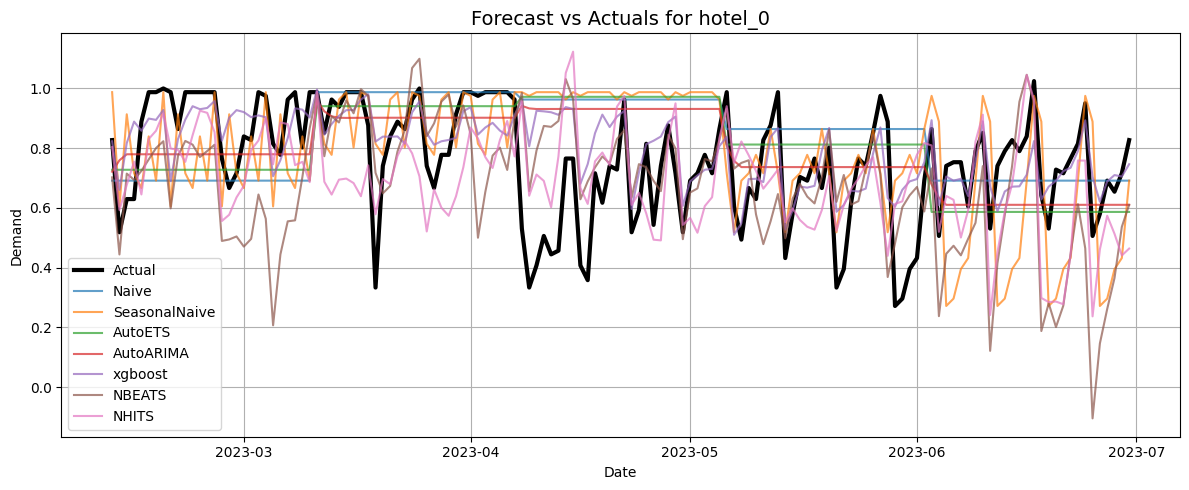

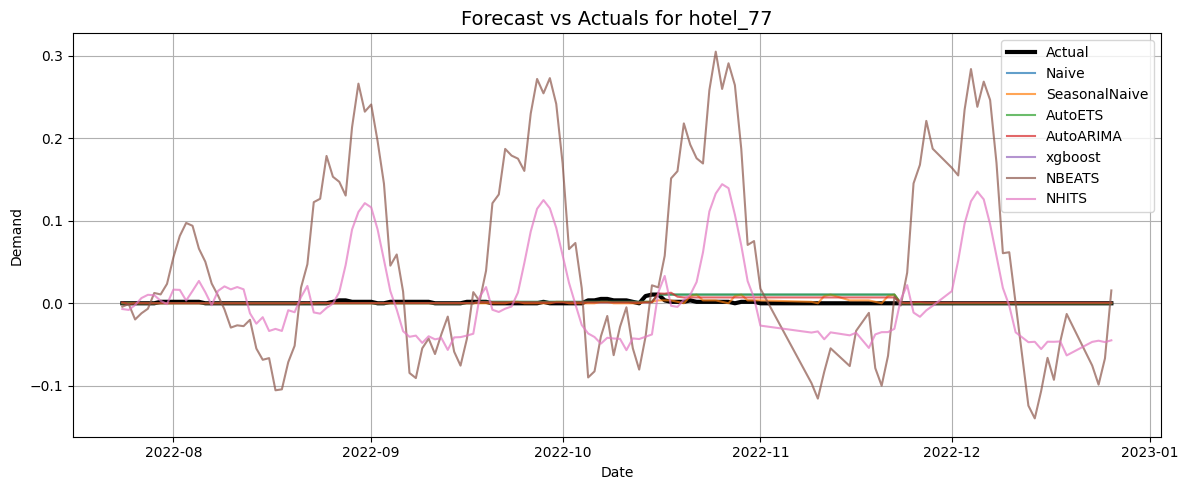

In [50]:
plot_forecasts_for_hotel("hotel_0")
plot_forecasts_for_hotel("hotel_77")


# Highlights Top Models

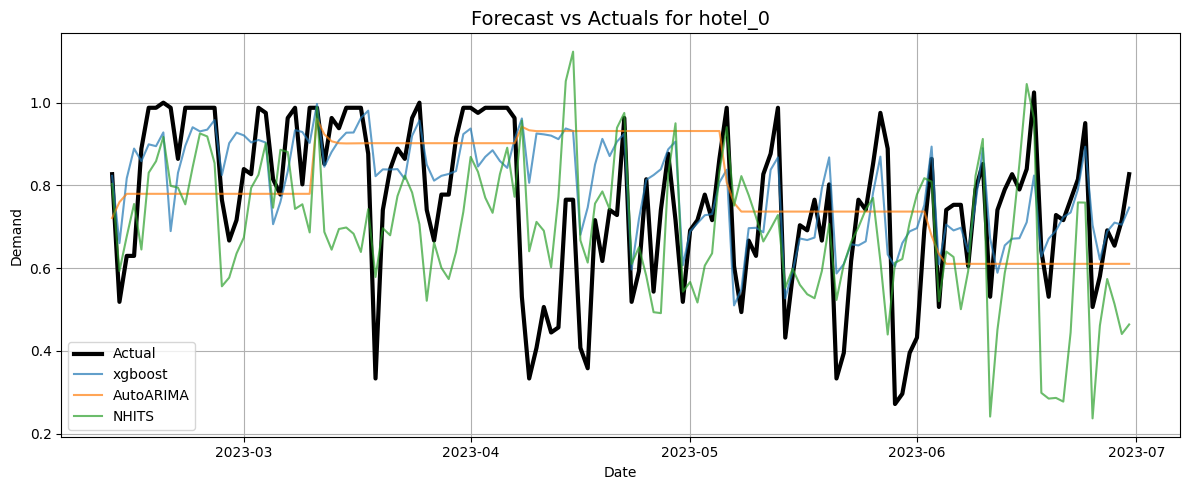

In [51]:
plot_forecasts_for_hotel("hotel_0", models_to_plot=["xgboost", "AutoARIMA", "NHITS"])


In [1]:
!pip install python-dotenv



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
import os
key = os.getenv("NIXTLA_API_KEY")
print("Loaded:", key[:8] + "*****")

Loaded: nixak-eX*****


In [13]:
!pip install nixtla


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.6/127.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.2/136.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 151.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 13.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [16]:
from nixtla import NixtlaClient

nixtla_client = NixtlaClient(api_key=key)

In [29]:
import pandas as pd

# Load the hotel dataset
df = pd.read_parquet("sample_hotels.parquet")
df.head()


,unique_id,ds,holiday_flag,target_day,target_month,target_year,location_type,hotel_type,y,otb_1,...,otb_51,otb_52,otb_53,otb_54,otb_55,otb_56,otb_57,otb_58,otb_59,otb_60
1430,hotel_0,2022-01-01,no,Sat,Jan,2022,NonSuburban,Resorts & Destinations,0.975309,0.679012,...,0.197531,0.197531,0.197531,0.185185,0.160494,0.160494,0.160494,0.160494,0.160494,0.160494
1431,hotel_0,2022-01-02,no,Sun,Jan,2022,NonSuburban,Resorts & Destinations,0.493827,0.308642,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.061728,0.061728,0.049383
1432,hotel_0,2022-01-03,no,Mon,Jan,2022,NonSuburban,Resorts & Destinations,0.456790,0.358025,...,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691
1433,hotel_0,2022-01-04,no,Tue,Jan,2022,NonSuburban,Resorts & Destinations,0.592593,0.419753,...,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.037037,0.037037,0.024691,0.024691
1434,hotel_0,2022-01-05,no,Wed,Jan,2022,NonSuburban,Resorts & Destinations,0.530864,0.407407,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.049383,0.049383,0.024691,0.024691,0.012346


In [57]:

ts_complete = (
    ts_df
    .sort_values(["unique_id", "ds"])
    .set_index("ds")                                  # use ds as index
    .groupby("unique_id", group_keys=False)           # group by hotel
    .apply(lambda g: g.asfreq("D"))                   # daily frequency
    .reset_index()                                    # back to columns: unique_id, ds, y
)

ts_complete.head()


,ds,unique_id,y
0,2022-01-01,hotel_0,0.975309
1,2022-01-02,hotel_0,0.493827
2,2022-01-03,hotel_0,0.456790
3,2022-01-04,hotel_0,0.592593
4,2022-01-05,hotel_0,0.530864


In [77]:
# Make 100% sure there are NO NaNs in y for any hotel
ts_complete["y"] = (
    ts_complete
    .groupby("unique_id")["y"]
    .transform(
        lambda s: (
            s.interpolate(limit_direction="both")  # smooth internal gaps
             .ffill()                              # fill any remaining with last value
             .bfill()                              # and next value if at the start
        )
    )
)

# As a last resort (in case an entire series was NaN), fill any leftover with 0
ts_complete["y"] = ts_complete["y"].fillna(0)

# Sanity check
print("NaNs remaining in y:", ts_complete["y"].isna().sum())


NaNs remaining in y: 0


In [38]:
from nixtla import NixtlaClient
nixtla_client = NixtlaClient(api_key=key)


In [87]:
# Ensure y is numeric
ts_complete["y"] = pd.to_numeric(ts_complete["y"], errors="coerce")

# (re-fill just in case converting to numeric produced new NaNs)
ts_complete["y"] = (
    ts_complete
    .groupby("unique_id")["y"]
    .transform(
        lambda s: (
            s.interpolate(limit_direction="both")
             .ffill()
             .bfill()
        )
    )
)
ts_complete["y"] = ts_complete["y"].fillna(0)

print("NaNs in y after numeric conversion:", ts_complete["y"].isna().sum())


NaNs in y after numeric conversion: 0


In [94]:
import pandas as pd
import numpy as np

# Keep only the three columns we need
tgpt_df = ts_complete[["unique_id", "ds", "y"]].copy()

# 1. Force ds to proper datetime
tgpt_df["ds"] = pd.to_datetime(tgpt_df["ds"], errors="coerce")

# 2. Force y to numeric
tgpt_df["y"] = pd.to_numeric(tgpt_df["y"], errors="coerce")

# 3. Drop rows where ds or y is completely unusable
tgpt_df = tgpt_df.dropna(subset=["ds", "y"])

print(tgpt_df.dtypes)
print("Any NaNs in y?", tgpt_df["y"].isna().sum())
print("Any NaNs in ds?", tgpt_df["ds"].isna().sum())


unique_id            object
ds           datetime64[ns]
y                   float64
dtype: object
Any NaNs in y? 0
Any NaNs in ds? 0


In [97]:
# Look for rows where y was originally non-numeric text
mask_weird_y = ts_complete["y"].apply(lambda v: isinstance(v, str))
print("Rows where original y is a string:", mask_weird_y.sum())
ts_complete.loc[mask_weird_y, ["unique_id", "ds", "y"]].head()


Rows where original y is a string: 0


,unique_id,ds,y


In [ ]:
# Inspect the types inside unique_id
tgpt_df['uid_type'] = tgpt_df['unique_id'].map(type)
print(tgpt_df['uid_type'].value_counts())
tgpt_df[['unique_id', 'uid_type']].head()


In [134]:

if 'uid_type' in tgpt_df.columns:
    tgpt_df = tgpt_df.drop(columns=['uid_type'])

# Force unique_id to string
tgpt_df['unique_id'] = tgpt_df['unique_id'].astype(str)

# Double-check
print(tgpt_df.dtypes)
print(tgpt_df['unique_id'].map(type).value_counts())


unique_id            object
ds           datetime64[ns]
y                   float64
dtype: object
unique_id
<class 'str'>    10188
Name: count, dtype: int64


In [138]:
import pandas as pd
import numpy as np

# Start from the daily-complete dataframe (the one you called ts_complete)
tgpt_df = ts_complete[["unique_id", "ds", "y"]].copy()

# 1. Force correct types
tgpt_df["unique_id"] = tgpt_df["unique_id"].astype(str)
tgpt_df["ds"]        = pd.to_datetime(tgpt_df["ds"])
tgpt_df["y"]         = pd.to_numeric(tgpt_df["y"], errors="coerce")

# 2. Remove any accidental duplicate id-date rows
dupes = tgpt_df.duplicated(subset=["unique_id", "ds"])
print("Duplicate id-date rows:", dupes.sum())
tgpt_df = tgpt_df[~dupes]

# 3. Fill missing y for each hotel (interpolate, then forward/back fill)
tgpt_df = tgpt_df.sort_values(["unique_id", "ds"])

tgpt_df["y"] = (
    tgpt_df
    .groupby("unique_id")["y"]
    .transform(lambda s: s.interpolate(limit_direction="both").ffill().bfill())
)


# 4. Final sanity checks
print(tgpt_df.dtypes)
print("Any NaNs in y?", tgpt_df["y"].isna().sum())


Duplicate id-date rows: 0
unique_id            object
ds           datetime64[ns]
y                   float64
dtype: object
Any NaNs in y? 0


In [144]:
H = 28
N_WINDOWS = 5

min_points = N_WINDOWS * H + 1   # 141 points per hotel

counts = tgpt_full.groupby("unique_id").size()
valid_ids = counts[counts >= min_points].index

print("Total hotels:", counts.shape[0])
print("Hotels with enough history:", len(valid_ids))

tgpt_long = (
    tgpt_full[tgpt_full["unique_id"].isin(valid_ids)]
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)


Total hotels: 20
Hotels with enough history: 19


In [147]:
H = 28           # 4 weeks ahead
N_WINDOWS = 5    # 5-fold time-series CV

tgpt_cv = nixtla_client.cross_validation(
    df=tgpt_long,      # <-- use the cleaned daily data
    h=H,
    freq="D",
    n_windows=N_WINDOWS,
)

tgpt_cv.head()


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Cross Validation Endpoint...


,unique_id,ds,cutoff,y,TimeGPT
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.764684
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.689710
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.724820
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.785021
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.797609


In [150]:
import numpy as np
import pandas as pd

def me(y, yhat):
    return np.mean(y - yhat)

def mae(y, yhat):
    return np.mean(np.abs(y - yhat))

def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

def mape(y, yhat):
    y = np.array(y)
    yhat = np.array(yhat)
    mask = y != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y[mask] - yhat[mask]) / y[mask]))

# overall TimeGPT metrics across all hotels & CV windows
tgpt_metrics_overall = pd.Series({
    "ME":   me(tgpt_cv["y"], tgpt_cv["TimeGPT"]),
    "MAE":  mae(tgpt_cv["y"], tgpt_cv["TimeGPT"]),
    "RMSE": rmse(tgpt_cv["y"], tgpt_cv["TimeGPT"]),
    "MAPE": mape(tgpt_cv["y"], tgpt_cv["TimeGPT"]),
})

tgpt_metrics_overall


ME      0.006481
MAE     0.105694
RMSE    0.149687
MAPE    0.229309
dtype: float64

In [162]:
# long-format row for overall TimeGPT metrics
tgpt_long = (
    tgpt_metrics_overall
    .reset_index()
    .rename(columns={"index": "metric", 0: "value"})
)
tgpt_long["model"] = "TimeGPT"





In [165]:
tgpt_long


,metric,value,model
0,ME,0.006481,TimeGPT
1,MAE,0.105694,TimeGPT
2,RMSE,0.149687,TimeGPT
3,MAPE,0.229309,TimeGPT


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=088240b9-4bb0-48b0-97d5-633dac7933c1' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>